Chapter 27
# 二元概率密度估计
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

In [1]:
import matplotlib.pyplot as plt

SciPy 也有完成概率密度估计的函数。图 25 所示为利用 scipy.stats.gaussian_kde()函数
估计得到的鸢尾花花萼宽、花萼长度联合概率密度函数。


在鸢尾花书《统计至简》中，大家会知道图 25 中曲面和水平面构成的体积为 1。

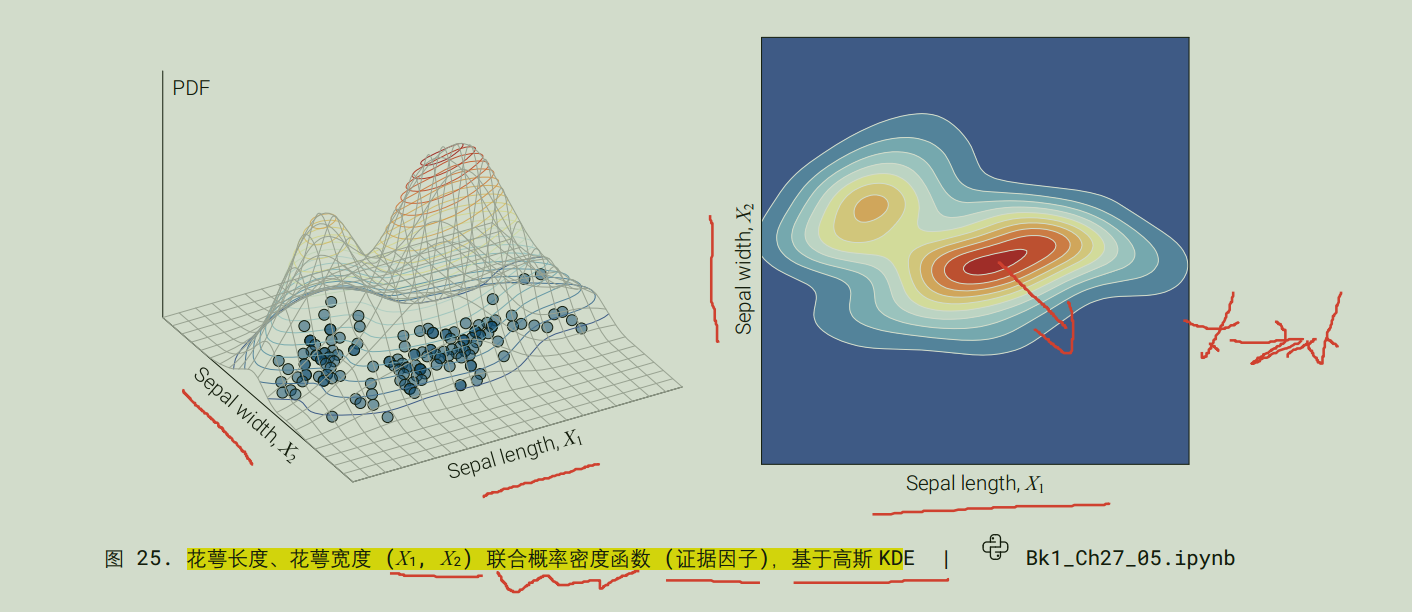

## 可视化函数

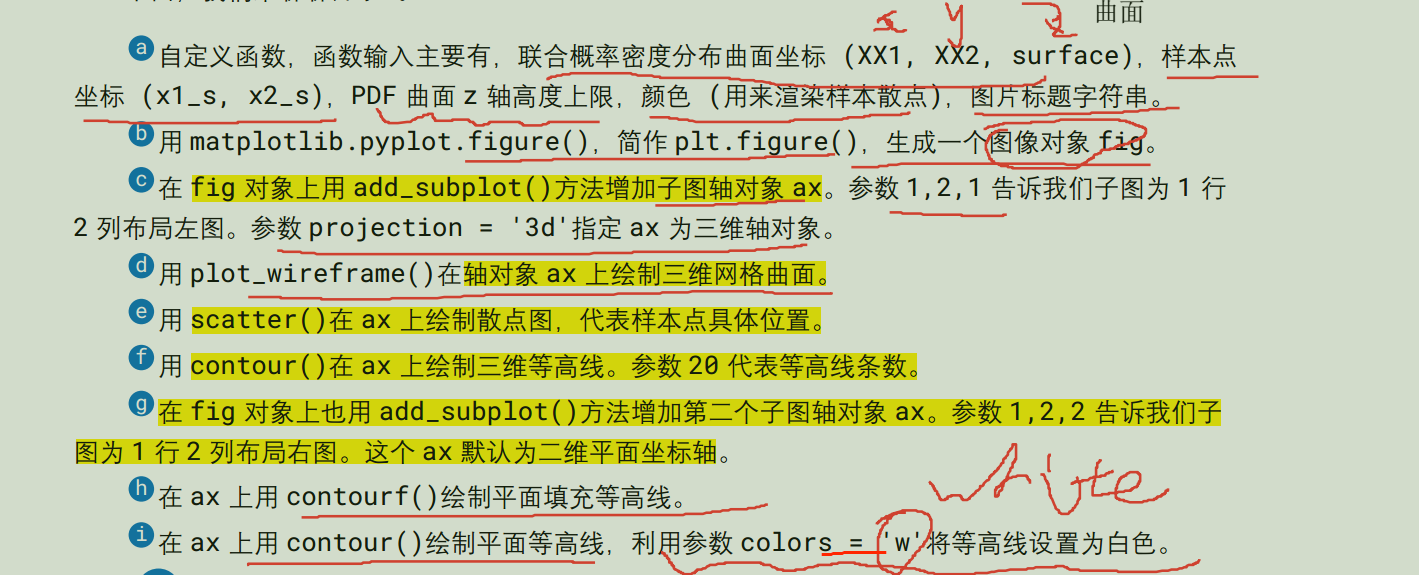

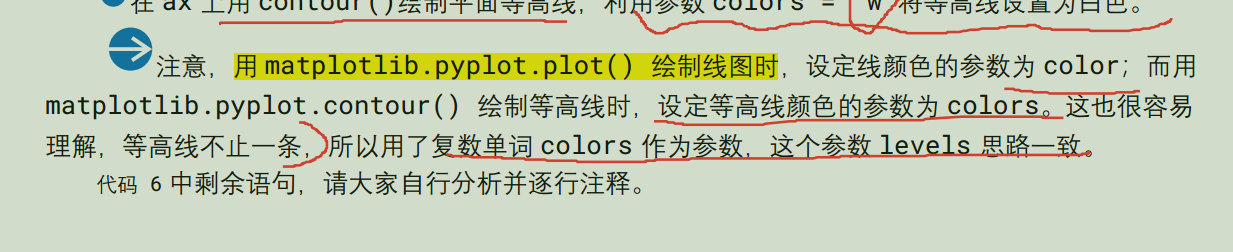

In [2]:
# 定义可视化函数
# 联合概率密度分布曲面坐标 (XX1, XX2, surface)，样本点
# 坐标 (x1_s, x2_s)，PDF 曲面 z 轴高度上限，颜色 (用来渲染样本散点)，图片标题字符串。
def plot_surface(xx1, xx2, surface, x1_s, x2_s,
                 z_height, color, title_txt):

    fig = plt.figure(figsize=(8,3)) # 图像对象fig

    ax = fig.add_subplot(1, 2, 1, projection='3d') # 两个子图；3d 选中第一个图；为3d
    # 绘制曲面 xx1, xx2, surface：x, y, z
    # 用 plot_wireframe()在轴对象 ax 上绘制三维网格曲面。
    '''
    rstrideRow Stride（行步长）沿 Y 轴方向（行）每隔多少个数据点取一个
    cstrideColumn Stride（列步长）沿 X 轴方向（列）每隔多少个数据点取一个
    '''
    ax.plot_wireframe(xx1, xx2, surface,
                      cstride = 8, rstride = 8,
                      color = [0.7,0.7,0.7], # 灰色
                      linewidth = 0.25) # 线宽

    # 用 scatter()在 ax 上绘制散点图，代表样本点具体位置。
    ax.scatter(x1_s, x2_s, x2_s*0, c=color) # 绘制散点图；z为0

    # 用 contour()在 ax 上绘制三维等高线。参数 20 代表等高线条数。
    ax.contour(xx1, xx2, surface,20,
                 cmap = 'RdYlBu_r')

    ax.set_proj_type('ortho') # 正交投影
    ax.set_xlabel('Sepal length, $x_1$') # 标签
    ax.set_ylabel('Sepal width, $x_2$')
    ax.set_zlabel('PDF')
    ax.set_xticks([]); ax.set_yticks([]) # 不显示刻度
    ax.set_zticks([])
    ax.set_xlim(x1.min(), x1.max())  # 范围
    ax.set_ylim(x2.min(), x2.max())
    ax.set_zlim([0,z_height])
    ax.view_init(azim=-120, elev=30) # 视角
    ax.set_title(title_txt)  # 标题
    ax.grid(False) # 不显示网格

    # 在 fig 对象上也用 add_subplot()方法增加第二个子图轴对象 ax。参数 1,2,2 告诉我们子图为 1 行 2 列布局右图。这个 ax 默认为二维平面坐标轴。
    ax = fig.add_subplot(1, 2, 2)

    # 前者是填充色块（contourf），后者是线条（contour）。
    ax.contourf(xx1, xx2, surface, 12, cmap='RdYlBu_r')
    ax.contour(xx1, xx2, surface, 12, colors='w')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlim(x1.min(), x1.max())
    ax.set_ylim(x2.min(), x2.max())
    ax.set_xlabel('Sepal length, $x_1$')
    ax.set_ylabel('Sepal width, $x_2$')
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(title_txt)

In [3]:
import numpy as np
import statsmodels.api as sm
import pandas as pd
from sklearn.datasets import load_iris
import scipy.stats as st

# 导入数据

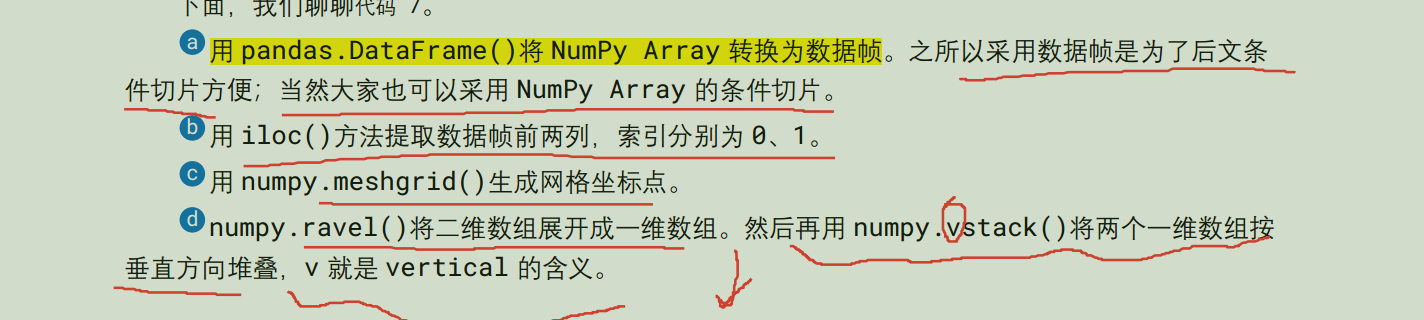

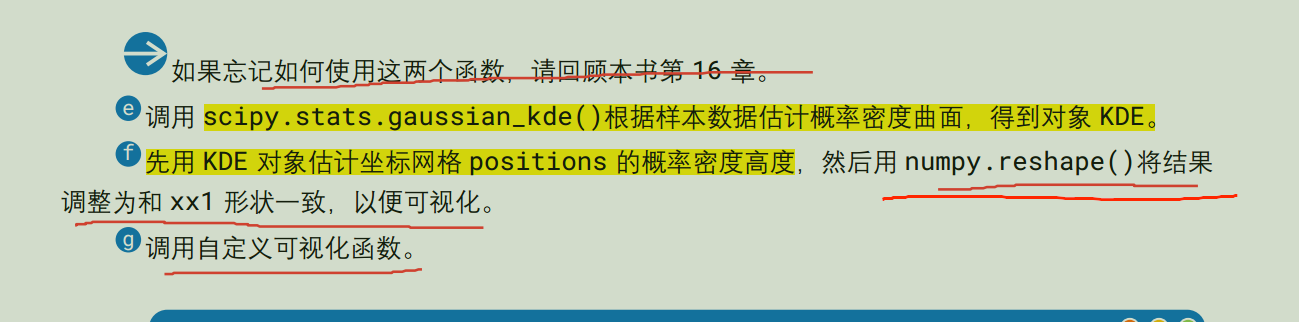

In [4]:
# 导入鸢尾花数据
iris = load_iris()
X_1_to_4 = iris.data; y = iris.target

In [5]:
# 特征名
feature_names = ['Sepal length, $X_1$','Sepal width, $X_2$',
                 'Petal length, $X_3$','Petal width, $X_4$']

X_df = pd.DataFrame(X_1_to_4) # 将数据转为数据帧
X1_2_df = X_df.iloc[:,[0,1]] # 取前两列数据

In [6]:
X1_2_df

,0,1
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6
...,...,...
145,6.7,3.0
146,6.3,2.5
147,6.5,3.0
148,6.2,3.4


In [8]:
xx1

array([[4.   , 4.025, 4.05 , ..., 7.95 , 7.975, 8.   ],
       [4.   , 4.025, 4.05 , ..., 7.95 , 7.975, 8.   ],
       [4.   , 4.025, 4.05 , ..., 7.95 , 7.975, 8.   ],
       ...,
       [4.   , 4.025, 4.05 , ..., 7.95 , 7.975, 8.   ],
       [4.   , 4.025, 4.05 , ..., 7.95 , 7.975, 8.   ],
       [4.   , 4.025, 4.05 , ..., 7.95 , 7.975, 8.   ]])

In [9]:
xx2

array([[1.   , 1.   , 1.   , ..., 1.   , 1.   , 1.   ],
       [1.025, 1.025, 1.025, ..., 1.025, 1.025, 1.025],
       [1.05 , 1.05 , 1.05 , ..., 1.05 , 1.05 , 1.05 ],
       ...,
       [4.95 , 4.95 , 4.95 , ..., 4.95 , 4.95 , 4.95 ],
       [4.975, 4.975, 4.975, ..., 4.975, 4.975, 4.975],
       [5.   , 5.   , 5.   , ..., 5.   , 5.   , 5.   ]])

numpy.ravel()将二维数组展开成一维数组。
然后再用 numpy.vstack()将两个一维数组按垂直方向堆叠，v 就是 vertical 的含义。


In [7]:
# 生成数据
x1 = np.linspace(4,8,161); x2 = np.linspace(1,5,161)
# 生成网格（从小到大）
xx1, xx2 = np.meshgrid(x1,x2)

# 也就是每一列就是一个点的坐标
positions = np.vstack([xx1.ravel(), xx2.ravel()])
colors = ['#FF3300','#0099FF','#8A8A8A']

In [10]:
positions # 也就是每一列就是一个点的坐标

array([[4.   , 4.025, 4.05 , ..., 7.95 , 7.975, 8.   ],
       [1.   , 1.   , 1.   , ..., 5.   , 5.   , 5.   ]])

调用 scipy.stats.gaussian_kde()根据样本数据估计概率密度曲面，得到对象 KDE。

先用 KDE 对象估计坐标网格 positions 的概率密度高度，然后用 numpy.reshape()将结果
调整为和 xx1 形状一致，以便可视化。


In [13]:
X1_2_df.values.T

array([[5.1, 4.9, 4.7, 4.6, 5. , 5.4, 4.6, 5. , 4.4, 4.9, 5.4, 4.8, 4.8,
        4.3, 5.8, 5.7, 5.4, 5.1, 5.7, 5.1, 5.4, 5.1, 4.6, 5.1, 4.8, 5. ,
        5. , 5.2, 5.2, 4.7, 4.8, 5.4, 5.2, 5.5, 4.9, 5. , 5.5, 4.9, 4.4,
        5.1, 5. , 4.5, 4.4, 5. , 5.1, 4.8, 5.1, 4.6, 5.3, 5. , 7. , 6.4,
        6.9, 5.5, 6.5, 5.7, 6.3, 4.9, 6.6, 5.2, 5. , 5.9, 6. , 6.1, 5.6,
        6.7, 5.6, 5.8, 6.2, 5.6, 5.9, 6.1, 6.3, 6.1, 6.4, 6.6, 6.8, 6.7,
        6. , 5.7, 5.5, 5.5, 5.8, 6. , 5.4, 6. , 6.7, 6.3, 5.6, 5.5, 5.5,
        6.1, 5.8, 5. , 5.6, 5.7, 5.7, 6.2, 5.1, 5.7, 6.3, 5.8, 7.1, 6.3,
        6.5, 7.6, 4.9, 7.3, 6.7, 7.2, 6.5, 6.4, 6.8, 5.7, 5.8, 6.4, 6.5,
        7.7, 7.7, 6. , 6.9, 5.6, 7.7, 6.3, 6.7, 7.2, 6.2, 6.1, 6.4, 7.2,
        7.4, 7.9, 6.4, 6.3, 6.1, 7.7, 6.3, 6.4, 6. , 6.9, 6.7, 6.9, 5.8,
        6.8, 6.7, 6.7, 6.3, 6.5, 6.2, 5.9],
       [3.5, 3. , 3.2, 3.1, 3.6, 3.9, 3.4, 3.4, 2.9, 3.1, 3.7, 3.4, 3. ,
        3. , 4. , 4.4, 3.9, 3.5, 3.8, 3.8, 3.4, 3.7, 3.6, 3.3, 3.4, 3. ,
       

In [14]:
positions.shape  # 161*161

(2, 25921)

In [16]:
KDE(positions).T

array([3.72322372e-11, 4.72224528e-11, 5.96006356e-11, ...,
       2.88766328e-11, 2.66991358e-11, 2.45751684e-11])

In [17]:
KDE(positions).T.shape

(25921,)

In [20]:
KDE(positions).shape

(25921,)

In [18]:
xx1.shape

(161, 161)

np.reshape：将一维密度数组转换为与 xx1 相同形状的二维矩阵，方便后续绘图。

In [15]:
# X1_2_df.values是原始数据的前两列(150*2)。转置(2*150)；每一列为一个坐标点
# scipy.stats.gaussian_kde()根据样本数据估计概率密度曲面，得到对象 KDE
KDE = st.gaussian_kde(X1_2_df.values.T) #
# 根据数据得到的KDE；带入生成的一系列点；得到 数据；
# 再将数据转为 与 xx1的形状类似 为 161*161
# 将161*161的一维数组转为xx1一样的二维数组
f_x1_x2 = np.reshape(KDE(positions).T, xx1.shape)

In [21]:
x1_s = X1_2_df.iloc[:,0] # 第一列数据
x2_s = X1_2_df.iloc[:,1] # 第二列数据

#可视化证据因子

In [ ]:
# 可视化证据因子

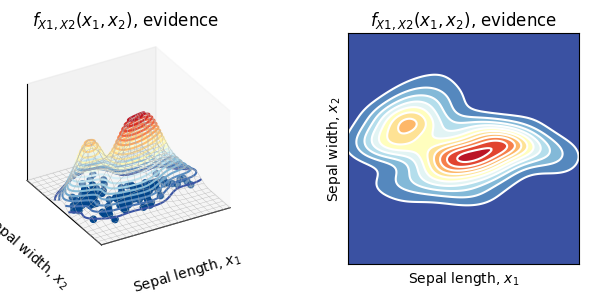

In [22]:
z_height = 0.5
title_txt = '$f_{X1, X2}(x_1, x_2)$, evidence'

# f_x1_x2为KDE计算坐标点的值；也就是z值； xx1, xx2：为网格点
# x1_s, x2_s（样本点的坐标）
plot_surface(xx1, xx2, f_x1_x2,
             x1_s, x2_s, z_height,
             '#00448A', title_txt)

#可视化似然函数

In [ ]:
# 可视化似然函数

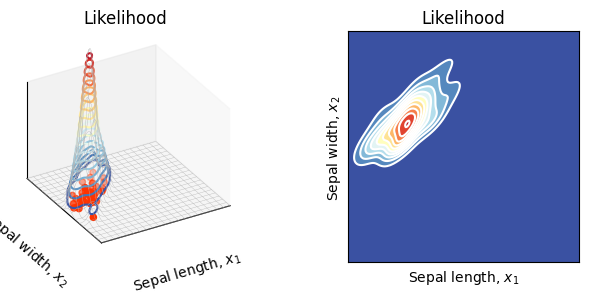

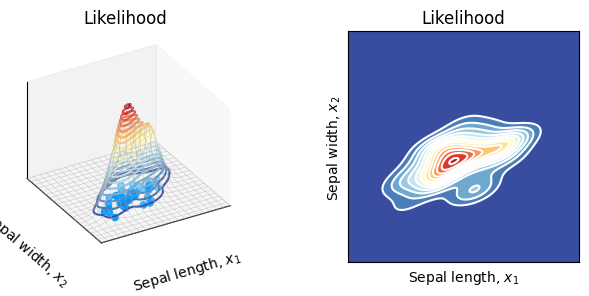

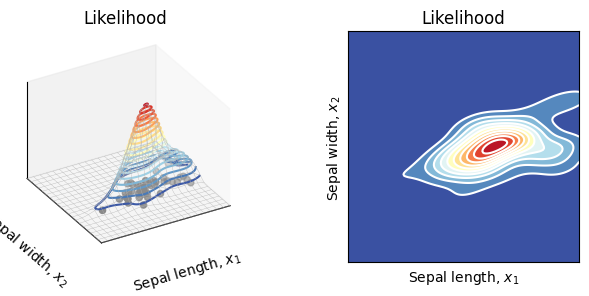

In [23]:
# 考虑不同鸢尾花分类
for idx in range(3):

    # 利用同种类的数据来得出概率密度函数KDE
    # 每一列就是一个坐标点
    KDE_idx = st.gaussian_kde(X1_2_df[y==idx].values.T)
    # 根据得出的KDE计算坐标点的z值； 并转为 161*161
    f_x1_x2_given_C_i = np.reshape(KDE_idx(positions).T, xx1.shape)

    # 取出原始数据的同种类数据；布尔
    x1_s_C_i = X1_2_df.iloc[:,0][y==idx]
    x2_s_C_i = X1_2_df.iloc[:,1][y==idx]

    z_height = 1
    title_txt = 'Likelihood'
    # f_x1_x2为KDE计算坐标点的值；也就是z值； xx1, xx2：为网格点
    # x1_s, x2_s（样本点的坐标）
    plot_surface(xx1, xx2, f_x1_x2_given_C_i,
                 x1_s_C_i, x2_s_C_i, z_height,
                 colors[idx], title_txt)

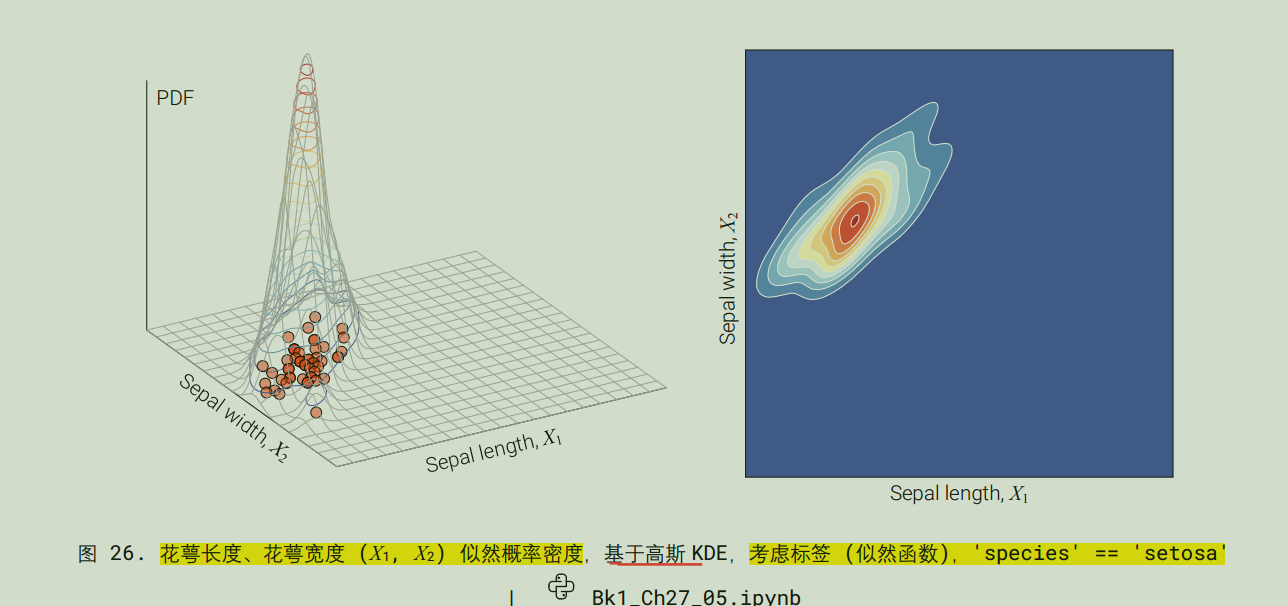

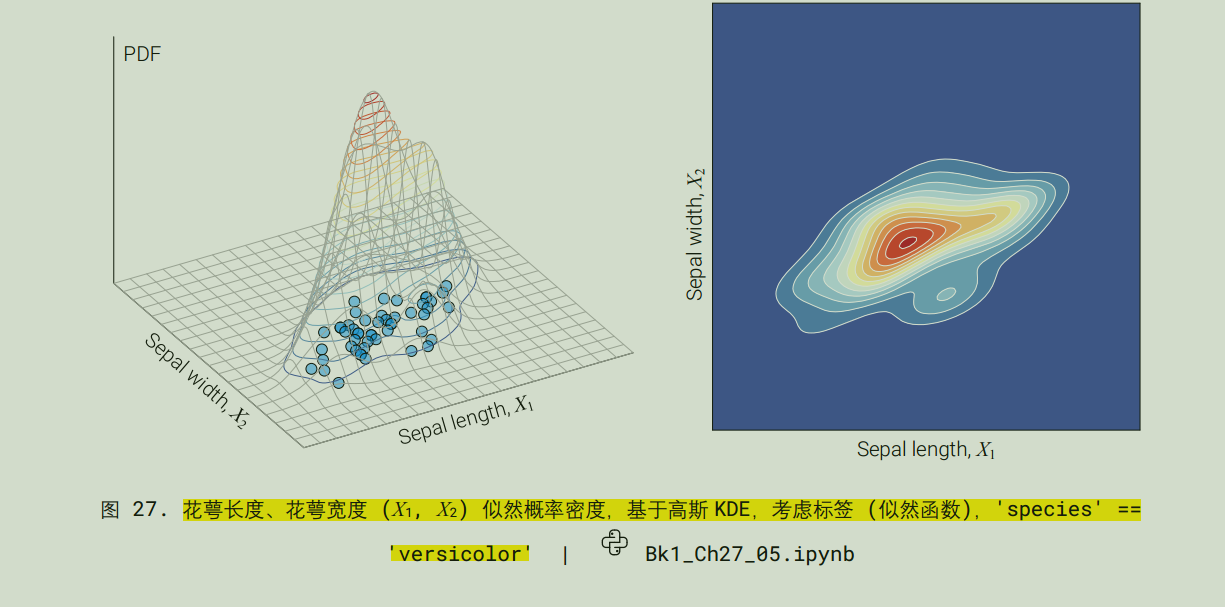

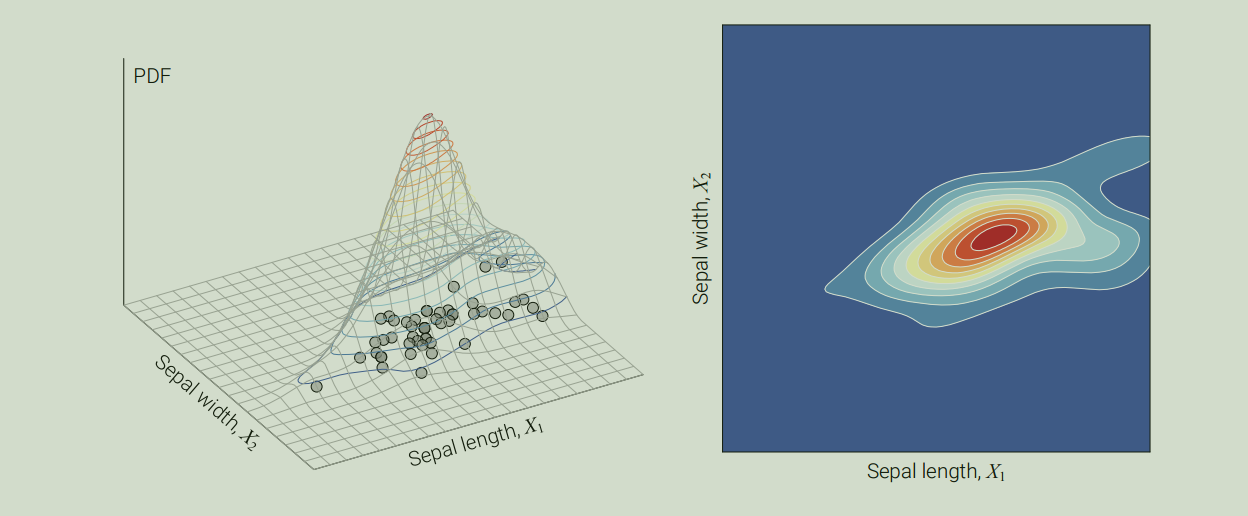

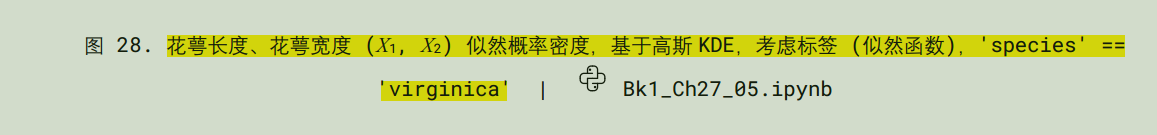

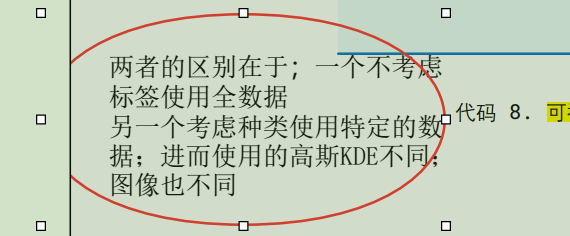

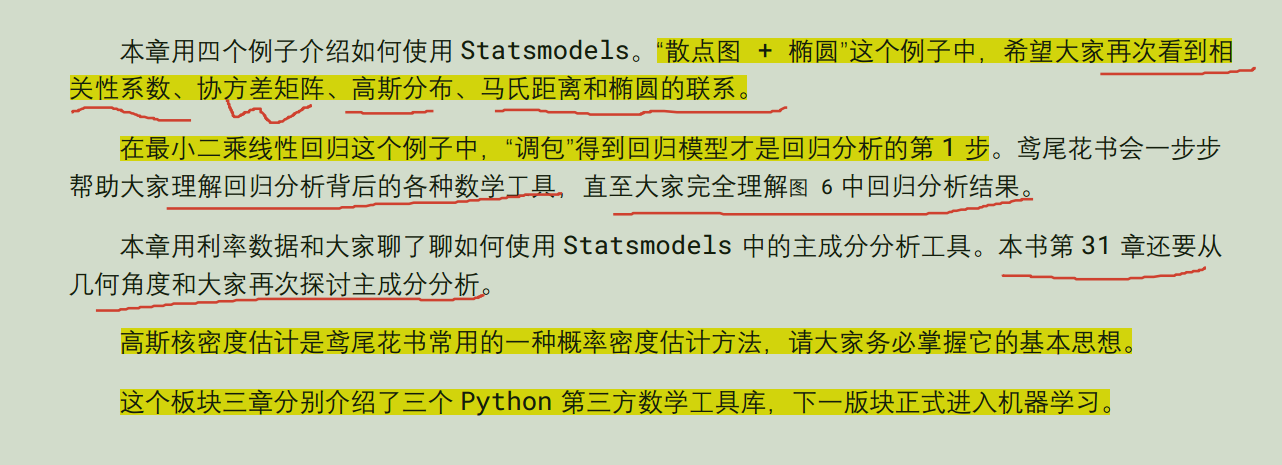